# Retail Weekly Sales Forecasting

Датасет: [Retail Store Sales Forecasting](https://www.kaggle.com/datasets/noopurbhatt/retail-store-sales-forecasting-dataset)

Файлы в `data/`:
- `sales.csv` — store_id, department, date, weekly_sales, is_holiday
- `features.csv` — temperature, fuel_price, markdowns, CPI, unemployment
- `stores.csv` — type, size, region

Целевой ряд по умолчанию — **сумма weekly_sales по всем магазинам/отделам** на неделю.
Метрики: MAE, RMSE, MAPE. Сплит по времени 70/15/15.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import load_data, load_raw, build_weekly_series
from src.features import build_ml_frame, get_feature_columns
from src.preprocessing import time_split, prepare_ml_matrices, to_series
from src.train import (
    forecast_naive, forecast_moving_average,
    train_sarima, forecast_sarima, select_sarima_order,
    train_prophet, forecast_prophet,
    train_xgboost, train_lightgbm, recursive_forecast_ml,
)
from src.evaluate import (
    print_metrics, results_table, plot_series, plot_decomposition,
    plot_acf_pacf, plot_forecast_compare, plot_residuals, save_model_bundle,
)
from src.utils import RANDOM_STATE, evaluate_forecast

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 4)
print('ok, ROOT =', ROOT)


ok, ROOT = d:\Projects_ML\Time_Series_Sales\time_series_sales


## 1. Данные

In [22]:
DATA_DIR = ROOT / 'data'

# суммарные данные по всем магазинам; для одного магазина: store_id=1
df = load_data(data_dir=DATA_DIR)
print('shape:', df.shape)
print('range:', df['ds'].min().date(), '->', df['ds'].max().date())
print('columns:', list(df.columns))
df.head()


shape: (156, 13)
range: 2022-01-01 -> 2024-12-21
columns: ['ds', 'y', 'is_holiday', 'n_rows', 'temperature', 'fuel_price', 'cpi', 'unemployment', 'markdown_1', 'markdown_2', 'markdown_3', 'markdown_4', 'markdown_5']


,ds,y,is_holiday,n_rows,temperature,fuel_price,cpi,unemployment,markdown_1,markdown_2,markdown_3,markdown_4,markdown_5
0,2022-01-01,70902987.20,1,1000,59.2822,4.1666,242.8678,6.1752,5822.2614,3124.4166,4401.6440,4139.8016,4775.5626
1,2022-01-08,56437421.26,0,1000,60.6580,3.8842,240.6908,6.3378,2418.0068,1556.3020,2015.7902,1879.6164,2177.5830
2,2022-01-15,55090458.09,0,1000,56.8810,4.0442,235.1006,6.1798,2023.4580,1570.7486,1740.8368,1878.8632,2323.8552
3,2022-01-22,56719185.29,0,1000,62.4832,3.9762,242.9762,5.8802,2173.1606,1472.0006,2047.0250,1833.5692,2084.1560
4,2022-01-29,55336034.35,0,1000,54.1376,4.1572,245.2032,6.2860,2780.7104,1375.9480,2151.3750,1696.8370,2362.9508


In [3]:
try:
    sales, features, stores = load_raw(DATA_DIR)
    print('sales rows:', len(sales), '| stores:', sales['store_id'].nunique(),
          '| depts:', sales['department'].nunique())
    print('features rows:', len(features), '| stores meta:', len(stores))
except FileNotFoundError as e:
    print(e)
    print('Используется заглушка. Положите CSV в data/ для реального прогона.')


sales rows: 156000 | stores: 50 | depts: 20
features rows: 7800 | stores meta: 50


## 2. EDA

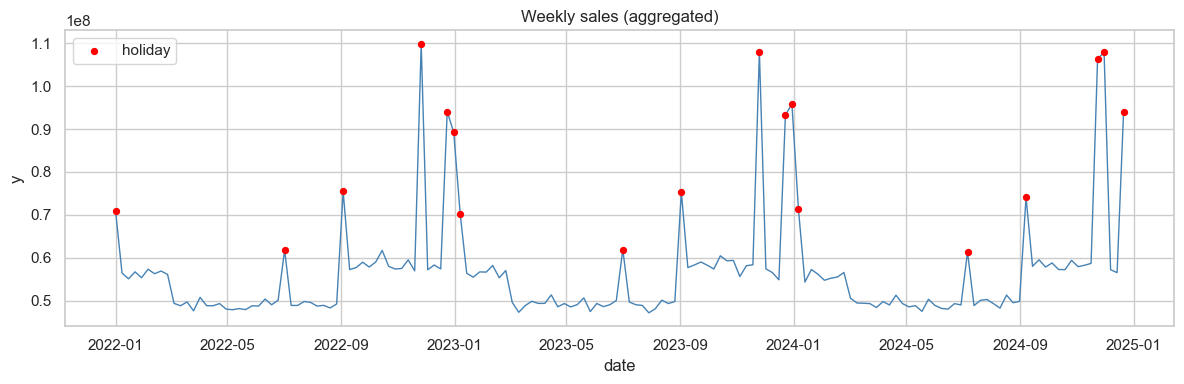

count    1.560000e+02
mean     5.650349e+07
std      1.230455e+07
min      4.717018e+07
25%      4.919367e+07
50%      5.481096e+07
75%      5.794087e+07
max      1.098518e+08
Name: y, dtype: float64


In [4]:
plot_series(df, title='Weekly sales (aggregated)')
plt.show()
print(df['y'].describe().round(2))


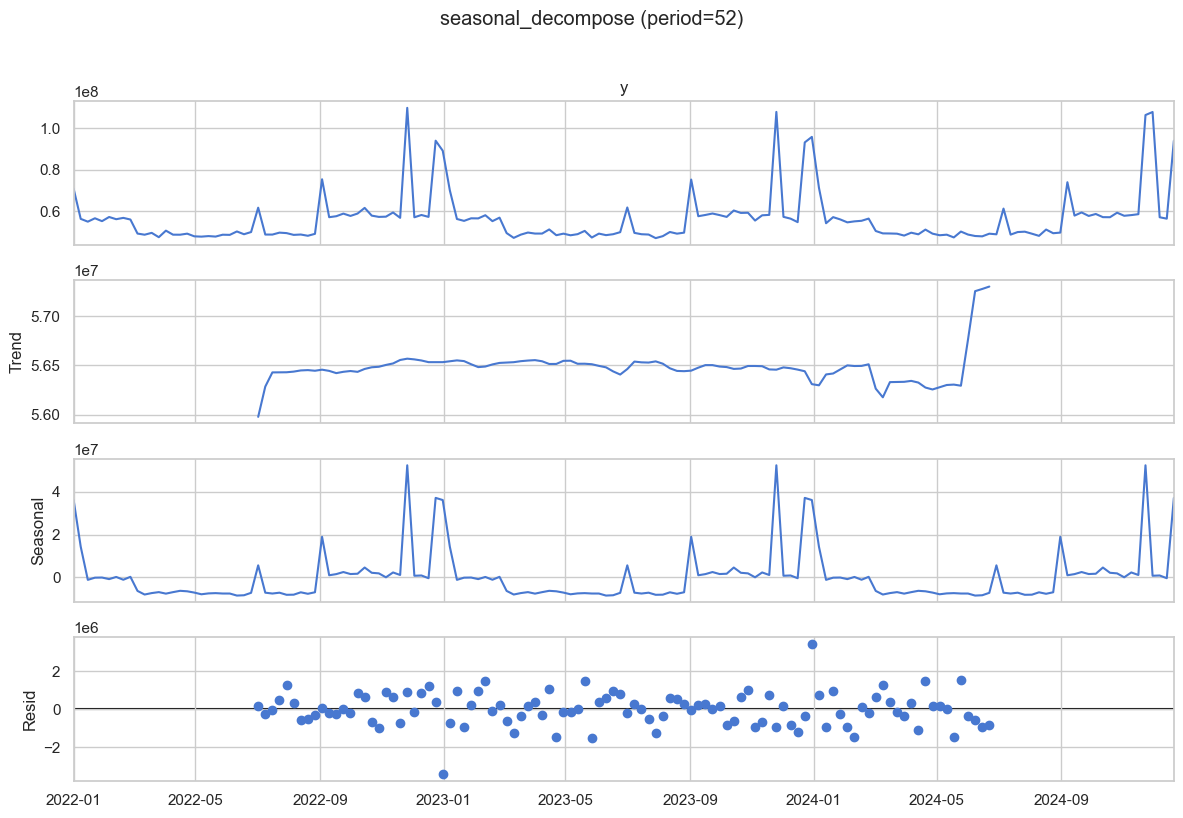

In [5]:
from statsmodels.tsa.seasonal import seasonal_decompose

y = to_series(df)
period = 52 if len(y) >= 104 else max(4, len(y) // 4)
decomp = seasonal_decompose(y.dropna(), model='additive', period=period)
plot_decomposition(decomp, title=f'seasonal_decompose (period={period})')
plt.show()


In [6]:
from statsmodels.tsa.stattools import adfuller

def adf_report(series, name='y'):
    s = series.dropna()
    stat, pval, *_ = adfuller(s, autolag='AIC')
    print(f'ADF {name}: stat={stat:.4f}, p-value={pval:.4g}')
    print('  stationary' if pval < 0.05 else '  non-stationary (trend/unit root)')

adf_report(y, 'raw')
adf_report(y.diff(), 'diff(1)')


ADF raw: stat=-2.3268, p-value=0.1635
  non-stationary (trend/unit root)
ADF diff(1): stat=-10.7013, p-value=3.518e-19
  stationary


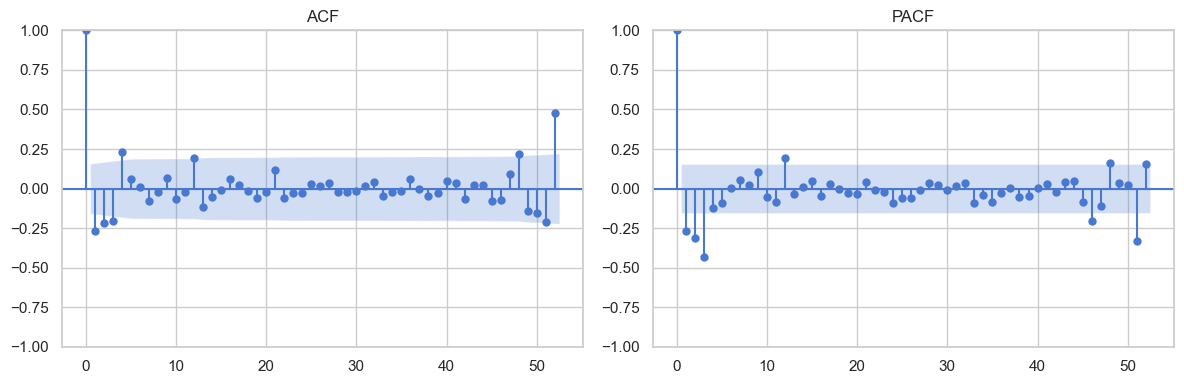

In [7]:
plot_acf_pacf(y.diff().dropna(), lags=min(52, max(10, len(y) // 3)))
plt.show()


## 3. Time-based split

train: 2022-01-01 → 2024-01-27  n=109
val:   2024-02-03 → 2024-07-06  n=23
test:  2024-07-13 → 2024-12-21  n=24


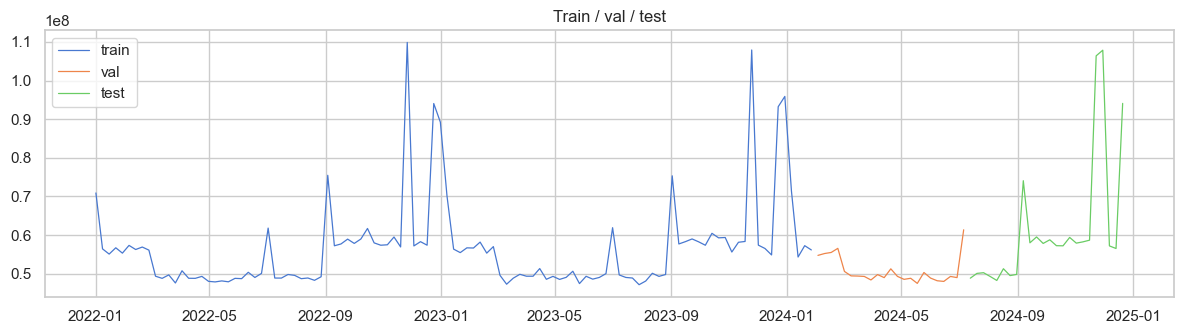

In [8]:
train_df, val_df, test_df = time_split(df, train_ratio=0.70, val_ratio=0.15)

print(f'train: {train_df.ds.min().date()} → {train_df.ds.max().date()}  n={len(train_df)}')
print(f'val:   {val_df.ds.min().date()} → {val_df.ds.max().date()}  n={len(val_df)}')
print(f'test:  {test_df.ds.min().date()} → {test_df.ds.max().date()}  n={len(test_df)}')

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(train_df.ds, train_df.y, label='train', lw=0.9)
ax.plot(val_df.ds, val_df.y, label='val', lw=0.9)
ax.plot(test_df.ds, test_df.y, label='test', lw=0.9)
ax.legend()
ax.set_title('Train / val / test')
plt.tight_layout()
plt.show()


## 4. Модели

In [9]:
results = {}
y_train_s = to_series(train_df)
y_val = val_df['y'].values
y_test = test_df['y'].values
h_val = len(val_df)
h_test = len(test_df)

hist_tv = pd.concat([train_df, val_df], ignore_index=True)
y_hist_tv = to_series(hist_tv)


### 4.1 Baseline

In [10]:
pred_naive_val = forecast_naive(y_train_s, h_val)
pred_ma_val = forecast_moving_average(y_train_s, h_val, window=4)

results['naive'] = evaluate_forecast(y_val, pred_naive_val)
results['ma_4'] = evaluate_forecast(y_val, pred_ma_val)
print_metrics('naive val', results['naive'])
print_metrics('ma_4 val', results['ma_4'])


naive val:
  MAE: 5843636.8804
  RMSE: 6339351.2032
  MAPE: 11.7884
ma_4 val:
  MAE: 9115882.1098
  RMSE: 9597557.2505
  MAPE: 18.3715


### 4.2 SARIMA

In [ ]:
order, seasonal_order, aic = select_sarima_order(y_train_s, seasonal_period=52)
print(f'order={order}, seasonal={seasonal_order}, AIC={aic:.1f}')

sarima_model = train_sarima(y_train_s, order=order, seasonal_order=seasonal_order)
pred_sarima_val, lo_v, hi_v = forecast_sarima(sarima_model, h_val)
results['SARIMA'] = evaluate_forecast(y_val, pred_sarima_val)
print_metrics('SARIMA val', results['SARIMA'])


### 4.3 Prophet

In [12]:
try:
    prophet_model = train_prophet(train_df)
    fc_val = forecast_prophet(
        prophet_model,
        periods=h_val,
        freq='W-FRI',
        future_regressors=val_df[['ds', 'is_holiday']] if 'is_holiday' in val_df.columns else None,
    )
    pred_prophet_val = fc_val.tail(h_val)['yhat'].values
    results['Prophet'] = evaluate_forecast(y_val, pred_prophet_val)
    print_metrics('Prophet val', results['Prophet'])
    prophet_ok = True
except Exception as e:
    print('Prophet unavailable:', type(e).__name__, str(e)[:200])
    prophet_ok = False


Prophet unavailable: ModuleNotFoundError No module named 'prophet'


### 4.4 LightGBM / XGBoost

In [13]:
X_train, y_tr, X_val, y_va, X_test, y_te, feat_cols, train_ml, val_ml, test_ml = prepare_ml_matrices(
    train_df, val_df, test_df
)
print(f'n features: {len(feat_cols)}')
print(feat_cols)
print(f'shapes: train={X_train.shape}, val={X_val.shape}, test={X_test.shape}')


n features: 30
['is_holiday', 'temperature', 'fuel_price', 'cpi', 'unemployment', 'markdown_1', 'markdown_2', 'markdown_3', 'markdown_4', 'markdown_5', 'weekofyear', 'month', 'quarter', 'year', 'weekofyear_sin', 'weekofyear_cos', 'month_sin', 'month_cos', 'lag_1', 'lag_2', 'lag_4', 'lag_8', 'lag_12', 'lag_52', 'roll_mean_4', 'roll_std_4', 'roll_mean_8', 'roll_std_8', 'roll_mean_12', 'roll_std_12']
shapes: train=(57, 30), val=(23, 30), test=(24, 30)


In [14]:
lgb_model = train_lightgbm(X_train, y_tr, X_val, y_va)

pred_lgb_os = lgb_model.predict(X_val)
results['LightGBM_onestep'] = evaluate_forecast(y_va.values, pred_lgb_os)
print_metrics('LightGBM one-step val', results['LightGBM_onestep'])

pred_lgb_val = recursive_forecast_ml(lgb_model, train_df, h_val, feat_cols)
results['LightGBM_recursive'] = evaluate_forecast(y_val, pred_lgb_val)
print_metrics('LightGBM recursive val', results['LightGBM_recursive'])


LightGBM one-step val:
  MAE: 2788388.1709
  RMSE: 3536248.3774
  MAPE: 5.5188
LightGBM recursive val:
  MAE: 6258471.0400
  RMSE: 6683561.2935
  MAPE: 12.3603


In [15]:
xgb_model = train_xgboost(X_train, y_tr, X_val, y_va)
pred_xgb_val = recursive_forecast_ml(xgb_model, train_df, h_val, feat_cols)
results['XGBoost_recursive'] = evaluate_forecast(y_val, pred_xgb_val)
print_metrics('XGBoost recursive val', results['XGBoost_recursive'])


XGBoost recursive val:
  MAE: 1836093.3139
  RMSE: 3342527.0197
  MAPE: 3.5050


### 4.5 Сравнение на валидации

In [16]:
res_df = results_table(results)
print(res_df.to_string())
best_name = res_df.index[0]
print(f'\nBest on val (RMSE): {best_name}')


                             MAE          RMSE     MAPE
XGBoost_recursive   1.836093e+06  3.342527e+06   3.5050
LightGBM_onestep    2.788388e+06  3.536248e+06   5.5188
naive               5.843637e+06  6.339351e+06  11.7884
LightGBM_recursive  6.258471e+06  6.683561e+06  12.3603
ma_4                9.115882e+06  9.597557e+06  18.3715
SARIMA              1.266147e+07  1.314148e+07  25.3460

Best on val (RMSE): XGBoost_recursive


## 5. Тест

In [21]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='statsmodels')
test_results = {}
forecasts_plot = {}
intervals = {}

pred_naive_te = forecast_naive(y_hist_tv, h_test)
pred_ma_te = forecast_moving_average(y_hist_tv, h_test, window=4)
test_results['naive'] = evaluate_forecast(y_test, pred_naive_te)
test_results['ma_4'] = evaluate_forecast(y_test, pred_ma_te)
forecasts_plot['ma_4'] = pred_ma_te

sarima_full = train_sarima(y_hist_tv, order=order, seasonal_order=seasonal_order)
pred_sarima_te, lo_t, hi_t = forecast_sarima(sarima_full, h_test)
test_results['SARIMA'] = evaluate_forecast(y_test, pred_sarima_te)
forecasts_plot['SARIMA'] = pred_sarima_te
intervals['SARIMA'] = (lo_t, hi_t)

if prophet_ok:
    prophet_full = train_prophet(hist_tv)
    fc_te = forecast_prophet(
        prophet_full,
        periods=h_test,
        freq='W-FRI',
        future_regressors=test_df[['ds', 'is_holiday']] if 'is_holiday' in test_df.columns else None,
    )
    tail = fc_te.tail(h_test)
    pred_prophet_te = tail['yhat'].values
    test_results['Prophet'] = evaluate_forecast(y_test, pred_prophet_te)
    forecasts_plot['Prophet'] = pred_prophet_te
    intervals['Prophet'] = (tail['yhat_lower'].values, tail['yhat_upper'].values)

pred_lgb_te = recursive_forecast_ml(lgb_model, hist_tv, h_test, feat_cols)
test_results['LightGBM'] = evaluate_forecast(y_test, pred_lgb_te)
forecasts_plot['LightGBM'] = pred_lgb_te

test_df_metrics = results_table(test_results)
print('=== Test ===')
print(test_df_metrics.to_string())
best_test = test_df_metrics.index[0]
print(f'\nBest on test: {best_test}')


=== Test ===
                   MAE          RMSE     MAPE
LightGBM  1.327878e+07  1.495944e+07  21.2079
naive     1.126391e+07  1.665691e+07  16.4554
SARIMA    1.046861e+07  1.855908e+07  13.3654
ma_4      1.109145e+07  1.922113e+07  14.1917

Best on test: LightGBM


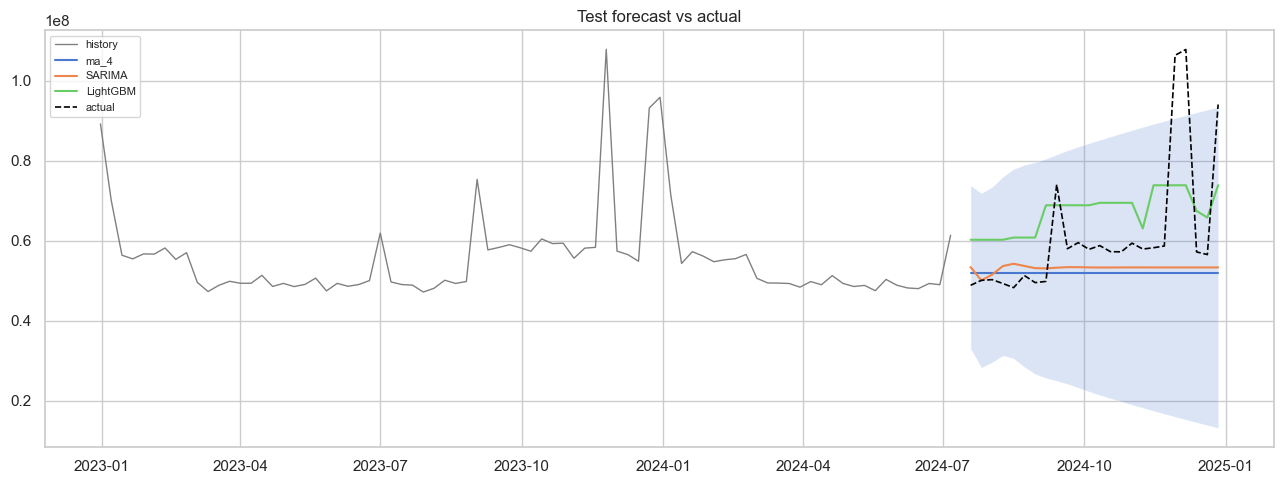

In [18]:
plot_forecast_compare(
    hist_tv,
    forecasts_plot,
    actual=y_test,
    title='Test forecast vs actual',
    intervals=intervals,
)
plt.show()


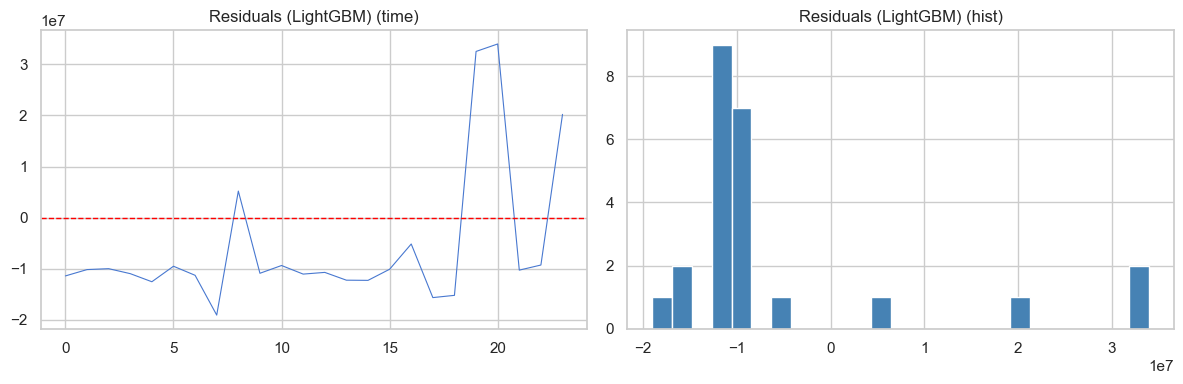

In [19]:
best_pred = forecasts_plot.get(best_test, pred_lgb_te)
plot_residuals(y_test, best_pred, title=f'Residuals ({best_test})')
plt.show()


## 6. Сохранение модели

In [20]:
model_path = Path('..') / 'models' / 'best_model.joblib'
if Path.cwd().name != 'notebooks':
    model_path = Path('models') / 'best_model.joblib'

if best_test == 'SARIMA':
    bundle_model = sarima_full
    meta = {'model_type': 'sarima', 'order': order, 'seasonal_order': seasonal_order}
elif best_test == 'Prophet' and prophet_ok:
    bundle_model = prophet_full
    meta = {'model_type': 'prophet'}
elif 'LightGBM' in str(best_test):
    bundle_model = lgb_model
    meta = {'model_type': 'lightgbm', 'feature_cols': feat_cols}
elif 'XGBoost' in str(best_test):
    bundle_model = xgb_model
    meta = {'model_type': 'xgboost', 'feature_cols': feat_cols}
elif best_test == 'ma_4':
    bundle_model = {'window': 4}
    meta = {'model_type': 'ma', 'window': 4}
else:
    bundle_model = None
    meta = {'model_type': 'naive'}

meta['test_metrics'] = test_results.get(best_test, {})
meta['best_name'] = best_test

save_model_bundle(model_path, bundle_model, meta=meta)
print(f'Saved → {model_path.resolve()}')
print(meta)


Saved → D:\Projects_ML\Time_Series_Sales\time_series_sales\models\best_model.joblib
{'model_type': 'lightgbm', 'feature_cols': ['is_holiday', 'temperature', 'fuel_price', 'cpi', 'unemployment', 'markdown_1', 'markdown_2', 'markdown_3', 'markdown_4', 'markdown_5', 'weekofyear', 'month', 'quarter', 'year', 'weekofyear_sin', 'weekofyear_cos', 'month_sin', 'month_cos', 'lag_1', 'lag_2', 'lag_4', 'lag_8', 'lag_12', 'lag_52', 'roll_mean_4', 'roll_std_4', 'roll_mean_8', 'roll_std_8', 'roll_mean_12', 'roll_std_12'], 'test_metrics': {'MAE': 13278781.68047292, 'RMSE': 14959440.973461542, 'MAPE': 21.20789529926812}, 'best_name': 'LightGBM'}


## 7. Выводы

- Ряд недельный → сезонность с period=52, не 7.
- `is_holiday`, markdowns и макро (CPI, unemployment) — полезные внешние сигналы для ML.
- One-step LightGBM завышает качество относительно multi-step; для сравнения с SARIMA/Prophet смотрим recursive.
- Агрегат по сети сглаживает шум; для inventory planning логичнее store/dept уровень.

Ограничения: один split, LOCF внешних признаков на горизонте, нет иерархии store→chain.